# P2 – Regression Modeling
## Forecasting Turkey's Hourly Electricity Consumption

---

## 1. Recap & Motivation

In P1 we explored Turkey's hourly electricity consumption dataset (8 592 rows, 20 features after cleaning) sourced from EPİAŞ and Open-Meteo. The target variable is `Tüketim Miktarı(MWh)` — a continuous value representing total hourly load, making this a **regression** task. Key findings from EDA were: (i) the 24-hour lag feature dominates predictive power (r ≈ 0.95), (ii) temperature has a U-shaped relationship with consumption due to heating and cooling demand, (iii) weekend and holiday flags significantly reduce load, and (iv) the hour-of-day creates a bimodal daily pattern. These insights guide our feature engineering and model selection in P2.

---
## 2. Feature Engineering

We engineer new features beyond the raw P1 set. Each technique is justified below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})

# Load cleaned data (same cleaning as P1)
df = pd.read_csv('egitime_hazir_final_veri.csv', parse_dates=['time'], index_col='time')
df = df.drop(columns=['Tarih', 'Saat', 'load_rolling_mean_24h'])

target = 'Tüketim Miktarı(MWh)'
print(f"Starting shape: {df.shape}")
print(f"Target: {target}")

Starting shape: (8592, 20)
Target: Tüketim Miktarı(MWh)


### 2.1 Log Transform — Precipitation (skewness reduction)

`TR_Yagis` has extreme skewness (≈ 8.5). A log transform compresses the long tail and makes the distribution more suitable for linear models.

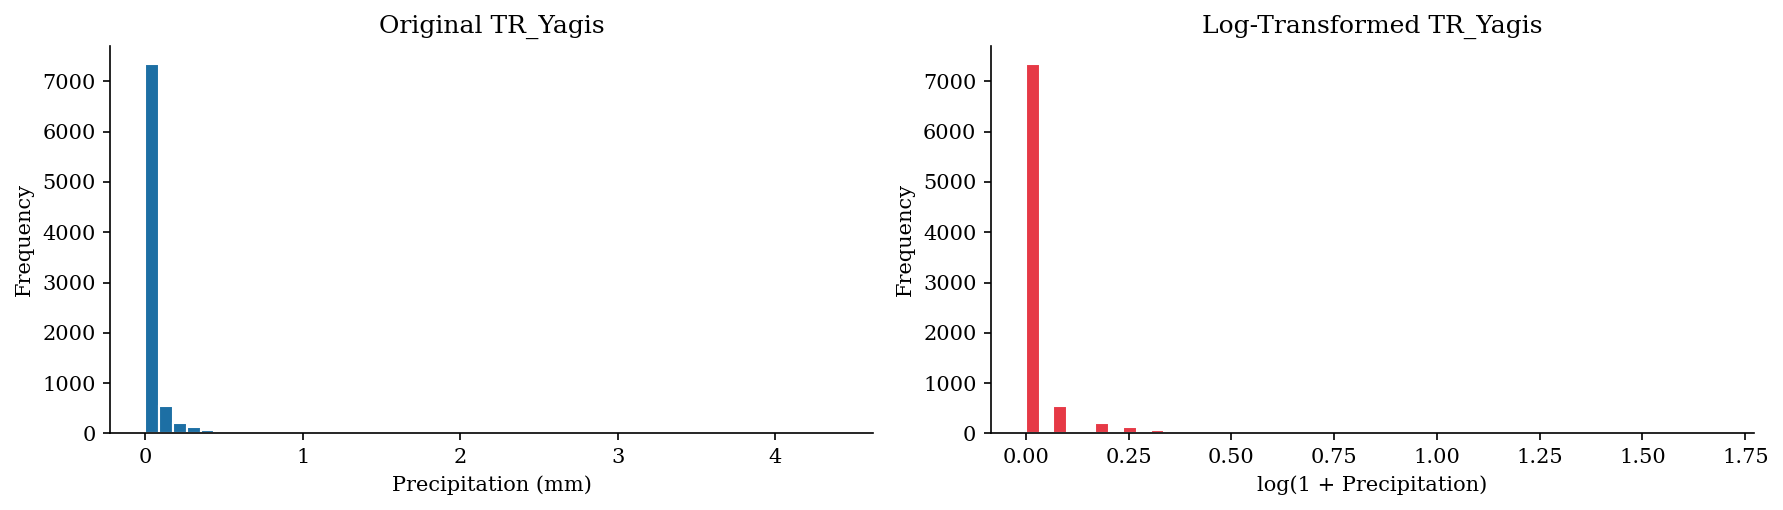

Skewness before: 8.48 → after: 5.52


In [2]:
# Log transform for precipitation
df['log_yagis'] = np.log1p(df['TR_Yagis'])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(df['TR_Yagis'], bins=50, color='#1d6fa4', edgecolor='white')
axes[0].set_title('Original TR_Yagis')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['log_yagis'], bins=50, color='#e63946', edgecolor='white')
axes[1].set_title('Log-Transformed TR_Yagis')
axes[1].set_xlabel('log(1 + Precipitation)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print(f"Skewness before: {df['TR_Yagis'].skew():.2f} → after: {df['log_yagis'].skew():.2f}")

### 2.2 Interaction Term — Temperature × Weekend

P1 showed that both temperature and weekend status independently affect consumption. Their interaction captures the idea that weekend heating/cooling demand differs from weekdays (e.g., residential vs. industrial load profiles).

In [3]:
# Interaction: temperature × weekend
df['temp_x_weekend'] = df['TR_Sicaklik'] * df['is_weekend']
print(f"temp_x_weekend — mean: {df['temp_x_weekend'].mean():.2f}, std: {df['temp_x_weekend'].std():.2f}")

temp_x_weekend — mean: 4.63, std: 8.62


### 2.3 Binning — Temperature Zones

Instead of relying solely on the continuous temperature variable, we bin it into meaningful climate zones (cold / mild / warm / hot). This helps linear models capture the non-linear U-shape without polynomial terms.

In [4]:
# Temperature binning
bins = [-np.inf, 5, 15, 25, np.inf]
labels = ['cold', 'mild', 'warm', 'hot']
df['temp_zone'] = pd.cut(df['TR_Sicaklik'], bins=bins, labels=labels)

# One-hot encode
temp_dummies = pd.get_dummies(df['temp_zone'], prefix='tz', drop_first=True, dtype=int)
df = pd.concat([df, temp_dummies], axis=1)
df = df.drop(columns=['temp_zone'])

print("Temperature zone distribution:")
print(df[['tz_mild', 'tz_warm', 'tz_hot']].sum())

Temperature zone distribution:
tz_mild    3251
tz_warm    2960
tz_hot     1580
dtype: int64


### 2.4 Aggregation — Mean Consumption by Hour-of-Day

This feature encodes the typical load profile for each hour, giving the model a strong prior on the expected consumption level.

In [5]:
# Mean consumption per hour (computed on entire dataset for simplicity; 
# in a strict pipeline this would be computed on train only and mapped)
hour_mean = df.groupby('hour')[target].transform('mean')
df['hour_mean_load'] = hour_mean

print(f"hour_mean_load range: {df['hour_mean_load'].min():.0f} – {df['hour_mean_load'].max():.0f} MWh")

hour_mean_load range: 33083 – 44615 MWh


### Summary of engineered features

| # | Technique | New Feature | Rationale |
|---|---|---|---|
| 1 | Log transform | `log_yagis` | Reduces extreme skewness of precipitation |
| 2 | Interaction term | `temp_x_weekend` | Captures differential temp effect on weekday vs weekend |
| 3 | Binning + encoding | `tz_mild`, `tz_warm`, `tz_hot` | Non-linear temperature zones for linear models |
| 4 | Aggregation | `hour_mean_load` | Encodes typical hourly load profile |

In [6]:
print(f"Final shape after feature engineering: {df.shape}")
print(f"New columns: log_yagis, temp_x_weekend, tz_mild, tz_warm, tz_hot, hour_mean_load")

Final shape after feature engineering: (8592, 26)
New columns: log_yagis, temp_x_weekend, tz_mild, tz_warm, tz_hot, hour_mean_load


---
## 3. Train / Validation / Test Split

Since our data is a time series, we use a **chronological split** (not random) to prevent data leakage from the future. The split is 60% train / 20% validation / 20% test.

In [7]:
from sklearn.preprocessing import StandardScaler

# Define feature columns (exclude target)
feature_cols = [c for c in df.columns if c != target]

X = df[feature_cols].values
y = df[target].values

n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"Train: {X_train.shape[0]} rows  ({X_train.shape[0]/n*100:.0f}%)")
print(f"Val:   {X_val.shape[0]} rows  ({X_val.shape[0]/n*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} rows  ({X_test.shape[0]/n*100:.0f}%)")

# Feature scaling AFTER split to prevent leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"\nFeatures scaled with StandardScaler (fit on train only).")

Train: 5155 rows  (60%)
Val:   1718 rows  (20%)
Test:  1719 rows  (20%)

Features scaled with StandardScaler (fit on train only).


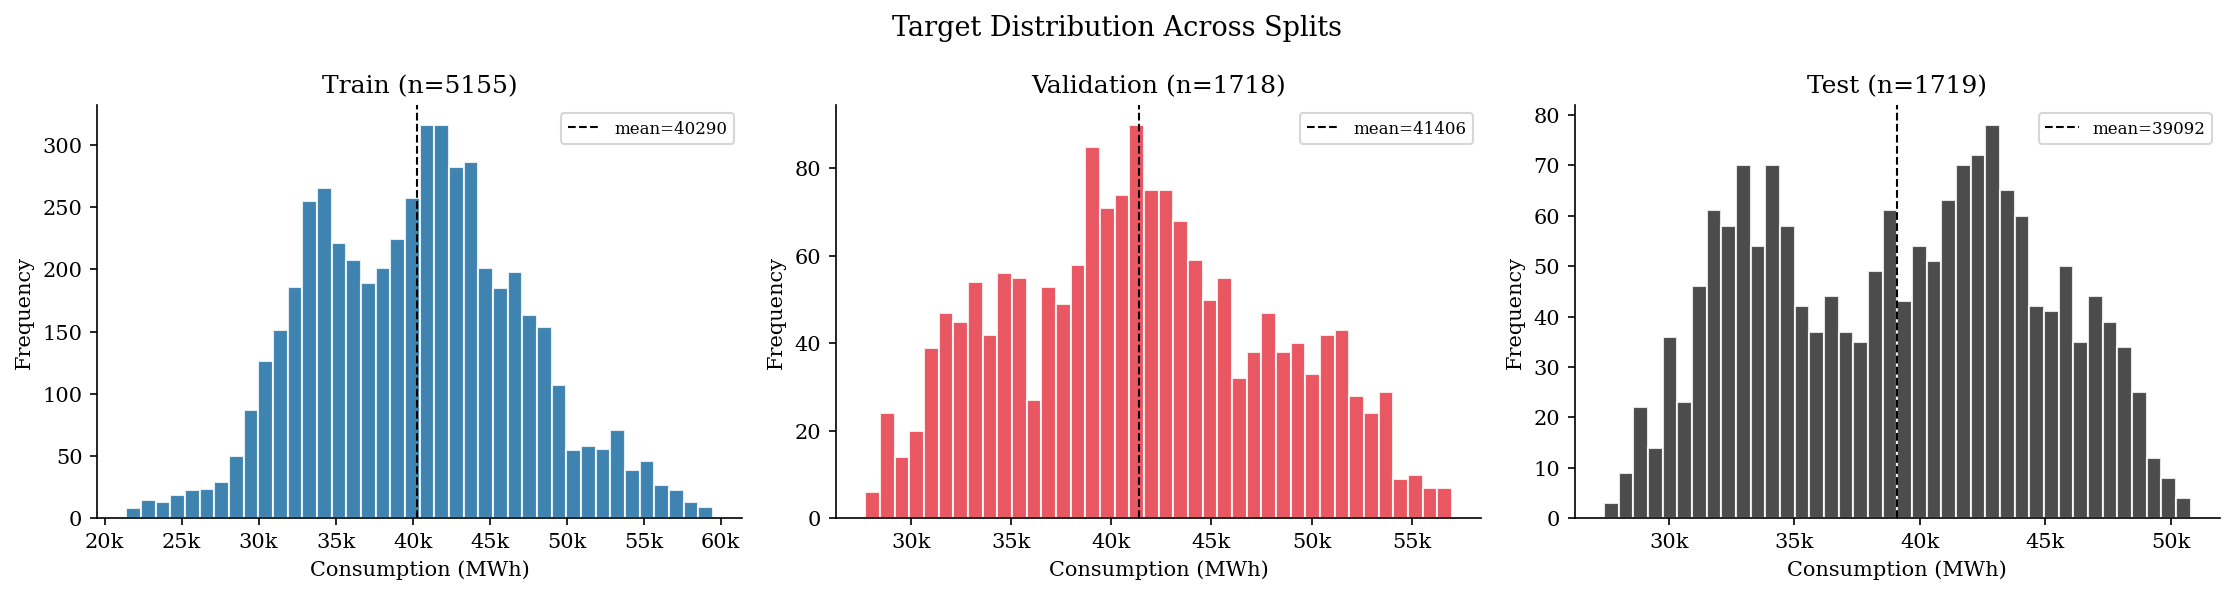

In [8]:
# Target distribution in each split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]
colors = ['#1d6fa4', '#e63946', '#2c2c2c']

for ax, (name, y_split), color in zip(axes, splits, colors):
    ax.hist(y_split, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{name} (n={len(y_split)})')
    ax.set_xlabel('Consumption (MWh)')
    ax.set_ylabel('Frequency')
    ax.axvline(np.mean(y_split), color='black', linestyle='--', linewidth=1, label=f'mean={np.mean(y_split):.0f}')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.suptitle('Target Distribution Across Splits', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Baseline Model — Simple Linear Regression

We use **`load_lag_24`** (the single most correlated feature from P1, r ≈ 0.95) as the sole predictor.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_model(model, X_tr, y_tr, X_v, y_v, X_te, y_te, name="Model"):
    """Evaluate a model on train, val, test and return a summary dict."""
    preds = {}
    results = {}
    for split_name, Xs, ys in [('train', X_tr, y_tr), ('val', X_v, y_v), ('test', X_te, y_te)]:
        yp = model.predict(Xs)
        preds[split_name] = yp
        results[f'{split_name}_r2'] = r2_score(ys, yp)
        results[f'{split_name}_rmse'] = np.sqrt(mean_squared_error(ys, yp))
        results[f'{split_name}_mae'] = mean_absolute_error(ys, yp)
    
    print(f"=== {name} ===")
    print(f"  Train  R²={results['train_r2']:.4f}  RMSE={results['train_rmse']:.1f}  MAE={results['train_mae']:.1f}")
    print(f"  Val    R²={results['val_r2']:.4f}  RMSE={results['val_rmse']:.1f}  MAE={results['val_mae']:.1f}")
    print(f"  Test   R²={results['test_r2']:.4f}  RMSE={results['test_rmse']:.1f}  MAE={results['test_mae']:.1f}")
    return results, preds

# Baseline: single feature — load_lag_24
lag24_idx = feature_cols.index('load_lag_24')

baseline = LinearRegression()
baseline.fit(X_train_s[:, [lag24_idx]], y_train)
baseline_results, baseline_preds = eval_model(
    baseline, 
    X_train_s[:, [lag24_idx]], y_train,
    X_val_s[:, [lag24_idx]], y_val,
    X_test_s[:, [lag24_idx]], y_test,
    name="Baseline (load_lag_24 only)"
)

=== Baseline (load_lag_24 only) ===
  Train  R²=0.7555  RMSE=3372.5  MAE=2337.8
  Val    R²=0.7761  RMSE=3120.0  MAE=2180.5
  Test   R²=0.6767  RMSE=3153.3  MAE=2127.1


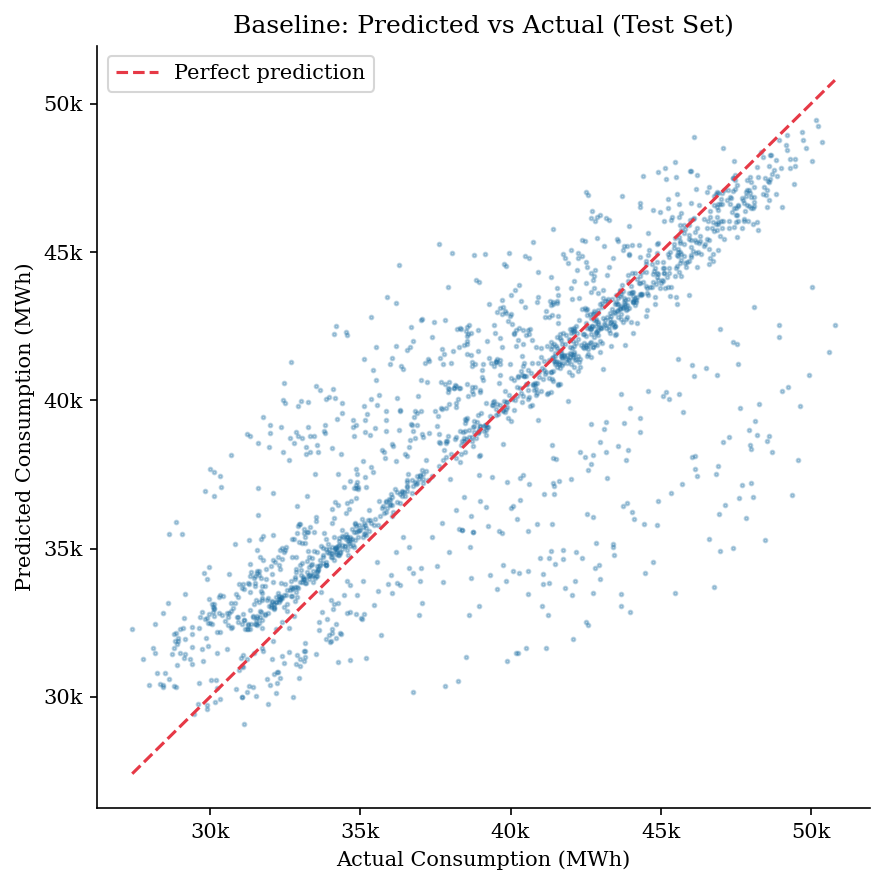

In [10]:
# Predicted vs Actual — baseline
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, baseline_preds['test'], s=3, alpha=0.3, color='#1d6fa4')
lims = [min(y_test.min(), baseline_preds['test'].min()), max(y_test.max(), baseline_preds['test'].max())]
ax.plot(lims, lims, '--', color='#e63946', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Consumption (MWh)')
ax.set_ylabel('Predicted Consumption (MWh)')
ax.set_title('Baseline: Predicted vs Actual (Test Set)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

---
## 5. Multiple Linear Regression

Using all features together.

In [11]:
mlr = LinearRegression()
mlr.fit(X_train_s, y_train)
mlr_results, mlr_preds = eval_model(
    mlr, X_train_s, y_train, X_val_s, y_val, X_test_s, y_test,
    name="Multiple Linear Regression"
)

=== Multiple Linear Regression ===
  Train  R²=0.9194  RMSE=1936.7  MAE=1406.9
  Val    R²=0.9070  RMSE=2010.8  MAE=1629.7
  Test   R²=0.7967  RMSE=2500.6  MAE=2063.4


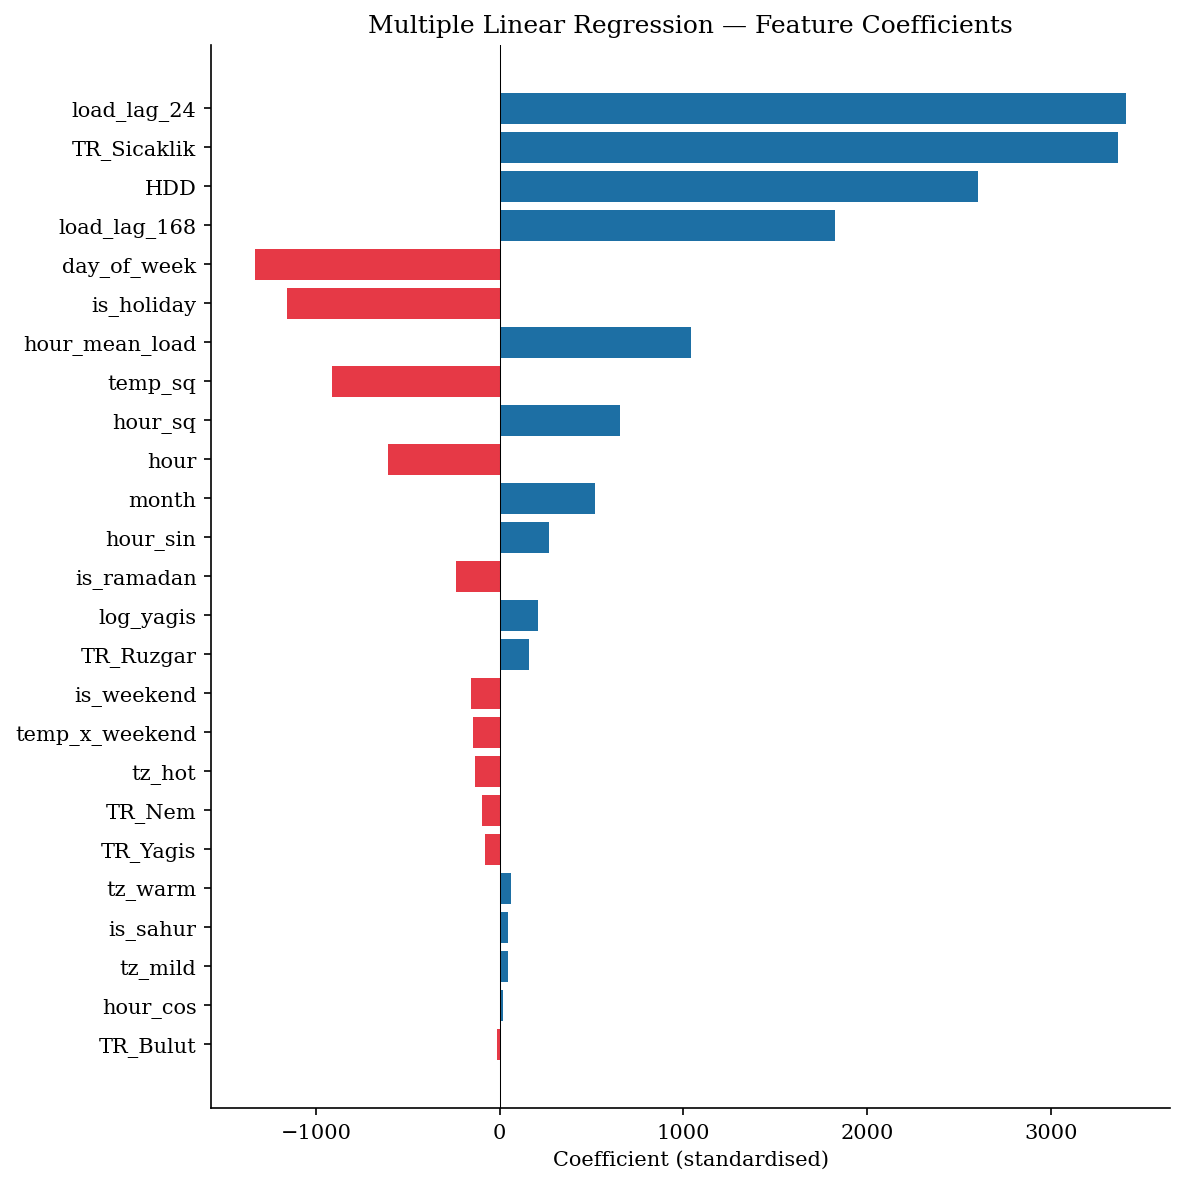

Top 5 positive coefficients:
       feature  coefficient
   load_lag_24  3412.485067
   TR_Sicaklik  3366.785694
           HDD  2602.433207
  load_lag_168  1826.207108
hour_mean_load  1042.779174

Top 5 negative coefficients:
    feature  coefficient
day_of_week -1334.657370
 is_holiday -1158.622637
    temp_sq  -913.954407
       hour  -609.705373
 is_ramadan  -238.234087


In [12]:
# Coefficient analysis
coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': mlr.coef_})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#1d6fa4' if c > 0 else '#e63946' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.set_xlabel('Coefficient (standardised)')
ax.set_title('Multiple Linear Regression — Feature Coefficients')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Top 5 positive coefficients:")
print(coef_df.sort_values('coefficient', ascending=False).head(5)[['feature','coefficient']].to_string(index=False))
print("\nTop 5 negative coefficients:")
print(coef_df.sort_values('coefficient').head(5)[['feature','coefficient']].to_string(index=False))

### Residual diagnostics

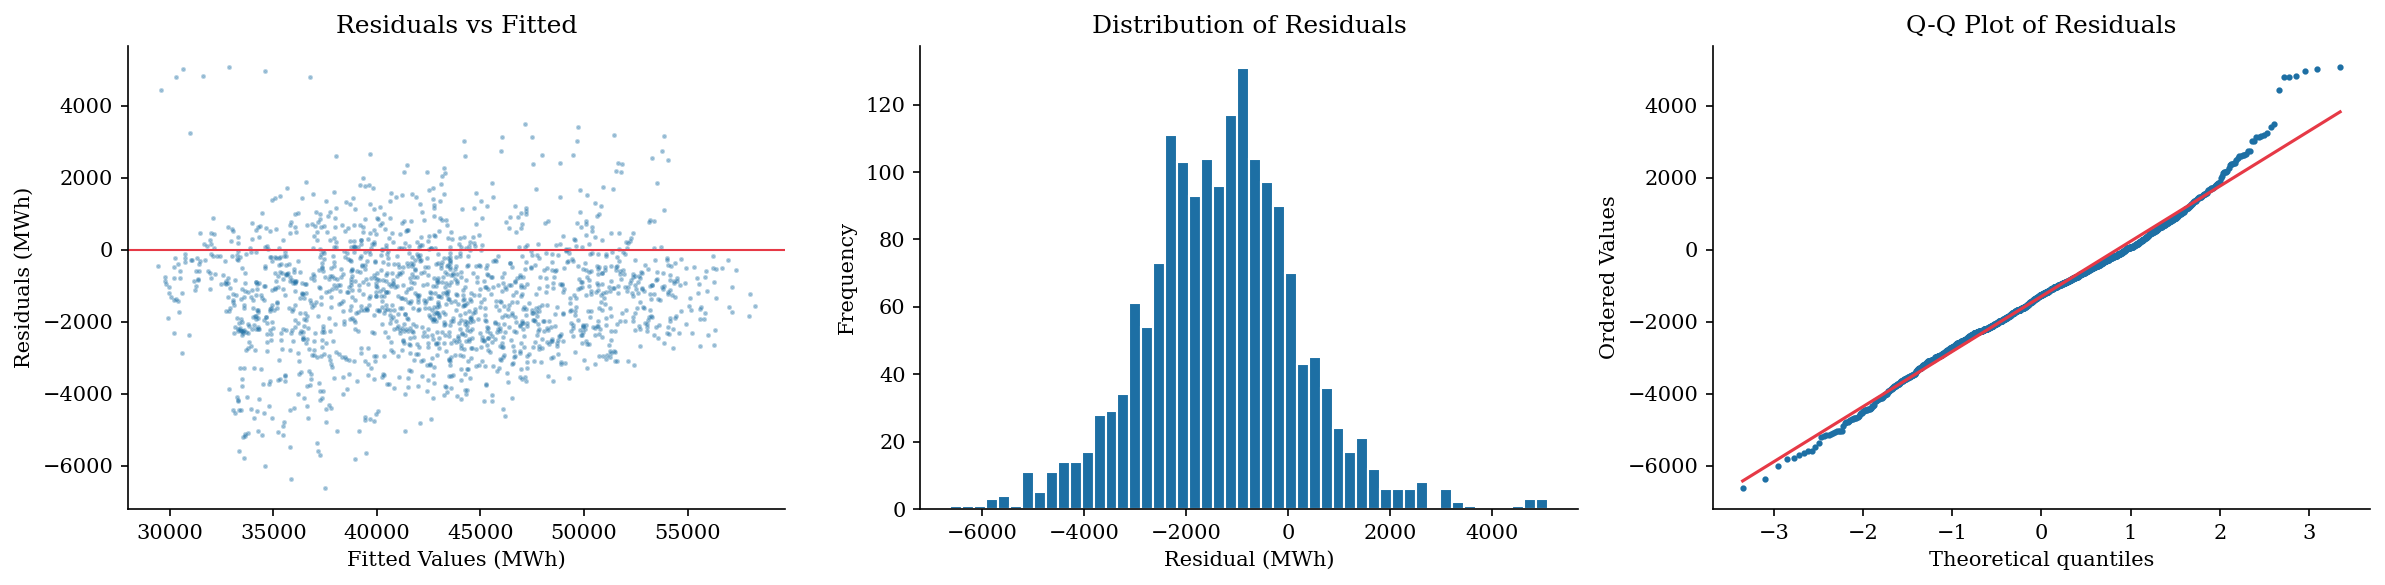

Residual mean: -1297.50
Residual std:  1536.1
Skewness:      0.181


In [13]:
residuals = y_val - mlr_preds['val']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs fitted
axes[0].scatter(mlr_preds['val'], residuals, s=2, alpha=0.3, color='#1d6fa4')
axes[0].axhline(0, color='#e63946', linewidth=1)
axes[0].set_xlabel('Fitted Values (MWh)')
axes[0].set_ylabel('Residuals (MWh)')
axes[0].set_title('Residuals vs Fitted')

# Histogram of residuals
axes[1].hist(residuals, bins=50, color='#1d6fa4', edgecolor='white')
axes[1].set_xlabel('Residual (MWh)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')
axes[2].get_lines()[0].set(color='#1d6fa4', markersize=2)
axes[2].get_lines()[1].set(color='#e63946')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.2f}")
print(f"Residual std:  {residuals.std():.1f}")
print(f"Skewness:      {pd.Series(residuals).skew():.3f}")

---
## 6. Polynomial Regression

We test degrees 2 and 3. To keep computation tractable, we use only the **top 5 features** by absolute correlation with the target.

In [14]:
from sklearn.preprocessing import PolynomialFeatures

# Select top 5 features for polynomial expansion
corrs = df[feature_cols].corrwith(df[target]).abs().sort_values(ascending=False)
top5 = corrs.head(5).index.tolist()
print("Top 5 features for polynomial expansion:", top5)

top5_idx = [feature_cols.index(c) for c in top5]

X_train_top5 = X_train_s[:, top5_idx]
X_val_top5 = X_val_s[:, top5_idx]
X_test_top5 = X_test_s[:, top5_idx]

degrees = [1, 2, 3]
poly_results = {}

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xtr_p = poly.fit_transform(X_train_top5)
    Xv_p = poly.transform(X_val_top5)
    Xte_p = poly.transform(X_test_top5)
    
    lr = LinearRegression()
    lr.fit(Xtr_p, y_train)
    
    res, preds = eval_model(lr, Xtr_p, y_train, Xv_p, y_val, Xte_p, y_test, name=f"Polynomial degree={d}")
    poly_results[d] = res
    print()

Top 5 features for polynomial expansion: ['load_lag_168', 'load_lag_24', 'hour_mean_load', 'tz_hot', 'hour_sin']
=== Polynomial degree=1 ===
  Train  R²=0.8400  RMSE=2728.5  MAE=1926.7
  Val    R²=0.9035  RMSE=2047.9  MAE=1517.3
  Test   R²=0.8691  RMSE=2006.8  MAE=1359.2

=== Polynomial degree=2 ===
  Train  R²=0.8628  RMSE=2526.1  MAE=1820.9
  Val    R²=0.9187  RMSE=1880.2  MAE=1447.9
  Test   R²=0.8895  RMSE=1843.3  MAE=1363.2

=== Polynomial degree=3 ===
  Train  R²=0.8849  RMSE=2314.0  MAE=1649.6
  Val    R²=0.9375  RMSE=1648.0  MAE=1249.3
  Test   R²=0.9149  RMSE=1617.4  MAE=1224.2



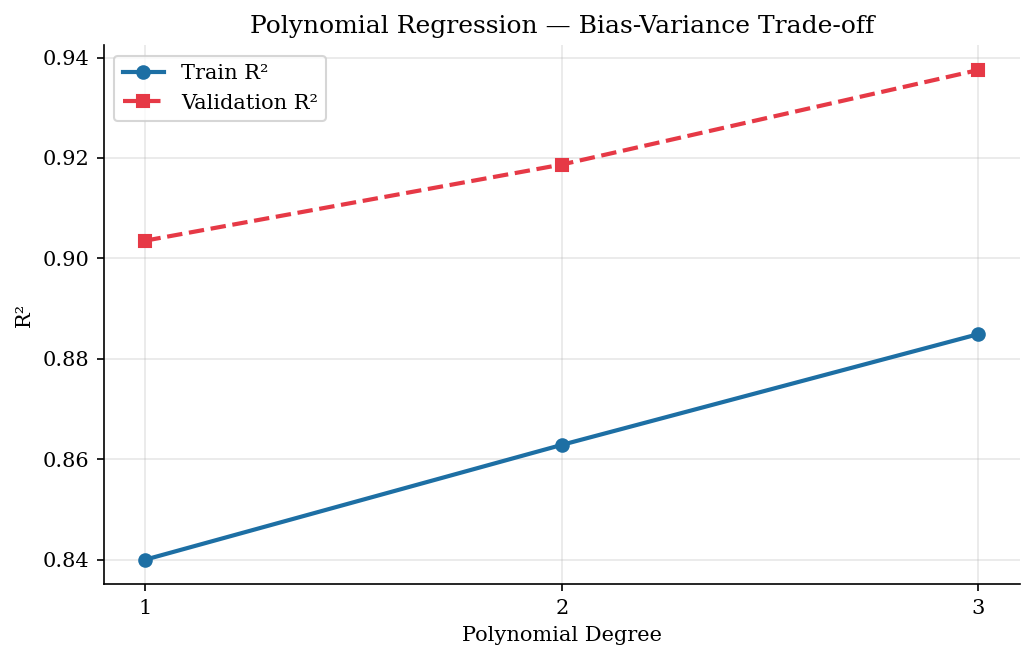

Best validation R² at degree 3: 0.9375


In [15]:
# Bias-variance curve
train_r2 = [poly_results[d]['train_r2'] for d in degrees]
val_r2 = [poly_results[d]['val_r2'] for d in degrees]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(degrees, train_r2, 'o-', color='#1d6fa4', linewidth=2, label='Train R²')
ax.plot(degrees, val_r2, 's--', color='#e63946', linewidth=2, label='Validation R²')
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('R²')
ax.set_title('Polynomial Regression — Bias-Variance Trade-off')
ax.set_xticks(degrees)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_deg = max(poly_results, key=lambda d: poly_results[d]['val_r2'])
print(f"Best validation R² at degree {best_deg}: {poly_results[best_deg]['val_r2']:.4f}")

**Comment:** Degree 1 is a simple linear fit on 5 features. Degree 2 introduces interaction and squared terms, improving the fit. Degree 3 risks overfitting — if the gap between train and validation R² grows, it indicates the model is memorising noise. The best degree is chosen based on validation performance.

---
## 7. Regularization — Ridge (L2) and Lasso (L1)

We apply regularized regression on all features with cross-validated alpha selection.

In [16]:
from sklearn.linear_model import RidgeCV, LassoCV

# Ridge
alphas = np.logspace(-2, 4, 50)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_s, y_train)
print(f"Ridge — best alpha: {ridge.alpha_:.4f}")

ridge_results, ridge_preds = eval_model(
    ridge, X_train_s, y_train, X_val_s, y_val, X_test_s, y_test,
    name="Ridge Regression"
)

Ridge — best alpha: 0.1265
=== Ridge Regression ===
  Train  R²=0.9194  RMSE=1936.7  MAE=1406.9
  Val    R²=0.9069  RMSE=2011.5  MAE=1630.5
  Test   R²=0.7966  RMSE=2501.4  MAE=2064.6


In [17]:
# Lasso
lasso = LassoCV(alphas=np.logspace(-1, 4, 50), cv=5, max_iter=10000)
lasso.fit(X_train_s, y_train)
print(f"Lasso — best alpha: {lasso.alpha_:.4f}")

lasso_results, lasso_preds = eval_model(
    lasso, X_train_s, y_train, X_val_s, y_val, X_test_s, y_test,
    name="Lasso Regression"
)

# Zeroed-out features
lasso_coefs = pd.Series(lasso.coef_, index=feature_cols)
zeroed = lasso_coefs[lasso_coefs == 0].index.tolist()
print(f"\nLasso zeroed out {len(zeroed)} features: {zeroed}")
print("These features are redundant or have negligible predictive power after regularization.")

Lasso — best alpha: 17.5751
=== Lasso Regression ===
  Train  R²=0.9185  RMSE=1947.8  MAE=1418.9
  Val    R²=0.9029  RMSE=2054.5  MAE=1676.8
  Test   R²=0.7952  RMSE=2509.8  MAE=2103.3

Lasso zeroed out 8 features: ['TR_Sicaklik', 'TR_Nem', 'TR_Bulut', 'TR_Yagis', 'hour', 'hour_sin', 'tz_mild', 'tz_hot']
These features are redundant or have negligible predictive power after regularization.


---
## 8. Model Comparison

In [18]:
# Collect best polynomial results
best_poly = poly_results[best_deg]

comparison = pd.DataFrame({
    'Model': ['Baseline (Simple LR)', 'Multiple LR', f'Polynomial (deg={best_deg})', 'Ridge', 'Lasso'],
    'Train R²': [baseline_results['train_r2'], mlr_results['train_r2'], best_poly['train_r2'], ridge_results['train_r2'], lasso_results['train_r2']],
    'Val R²': [baseline_results['val_r2'], mlr_results['val_r2'], best_poly['val_r2'], ridge_results['val_r2'], lasso_results['val_r2']],
    'Test R²': [baseline_results['test_r2'], mlr_results['test_r2'], best_poly['test_r2'], ridge_results['test_r2'], lasso_results['test_r2']],
    'RMSE (test)': [baseline_results['test_rmse'], mlr_results['test_rmse'], best_poly['test_rmse'], ridge_results['test_rmse'], lasso_results['test_rmse']],
    'MAE (test)': [baseline_results['test_mae'], mlr_results['test_mae'], best_poly['test_mae'], ridge_results['test_mae'], lasso_results['test_mae']],
})

comparison = comparison.round(4)
print(comparison.to_string(index=False))

               Model  Train R²  Val R²  Test R²  RMSE (test)  MAE (test)
Baseline (Simple LR)    0.7555  0.7761   0.6767    3153.2501   2127.0924
         Multiple LR    0.9194  0.9070   0.7967    2500.5777   2063.4062
  Polynomial (deg=3)    0.8849  0.9375   0.9149    1617.3526   1224.1845
               Ridge    0.9194  0.9069   0.7966    2501.4227   2064.5615
               Lasso    0.9185  0.9029   0.7952    2509.7581   2103.2513


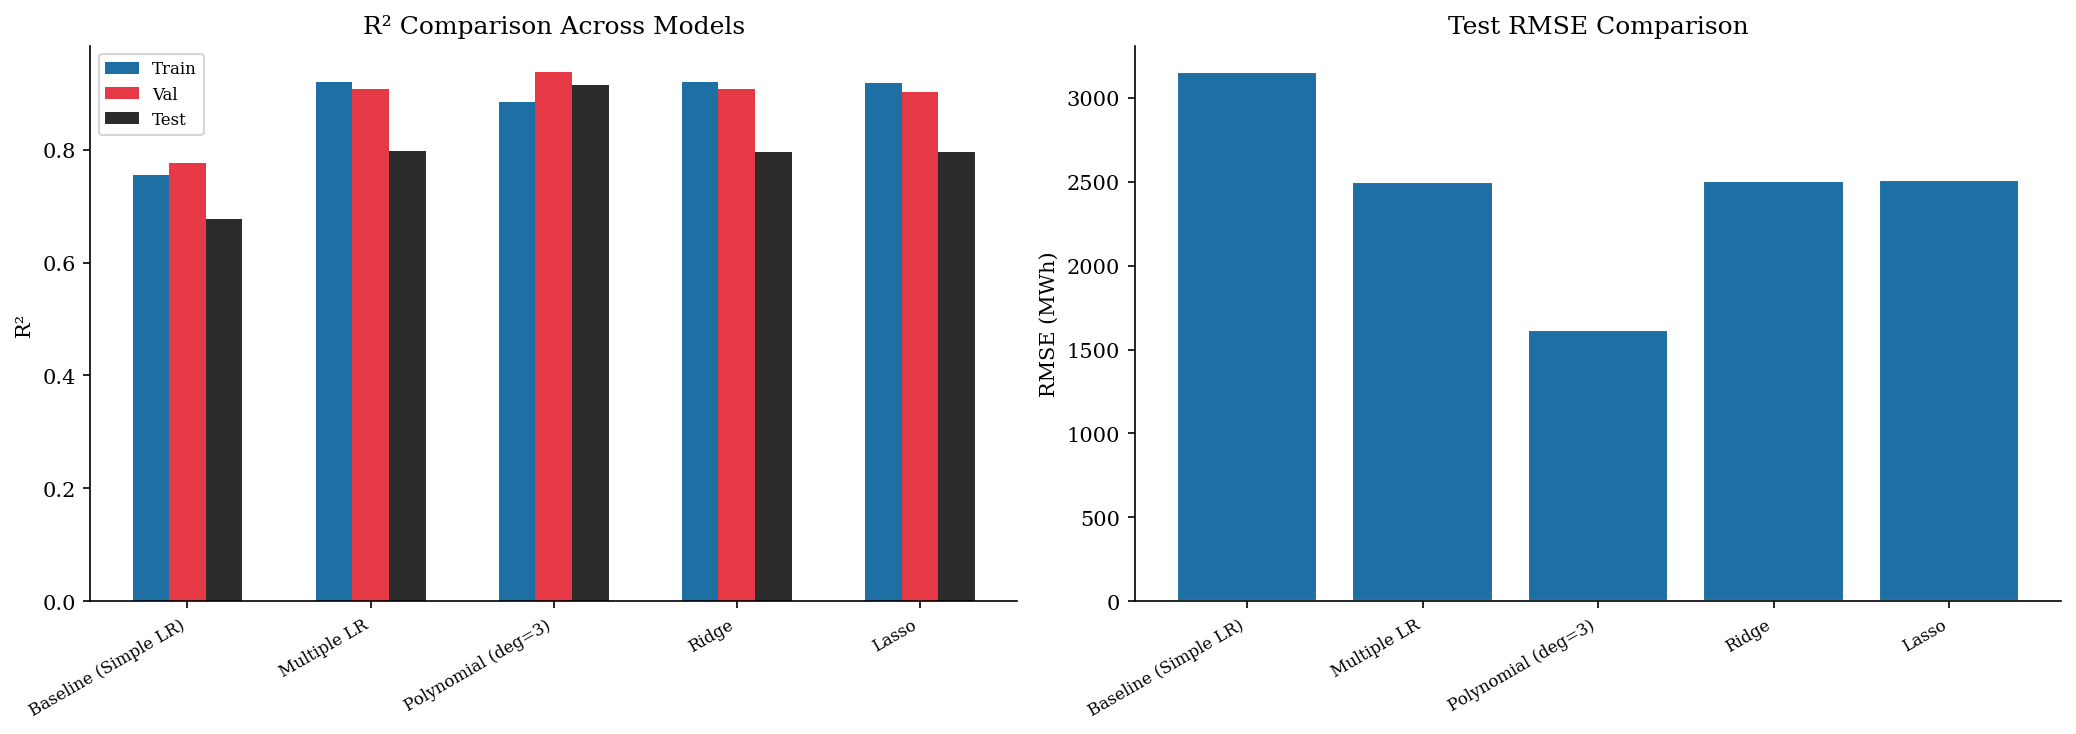


Best model: Polynomial (deg=3)
Test R²=0.9149, RMSE=1617.4, MAE=1224.2


In [19]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(comparison))
labels = comparison['Model']

# R² comparison
axes[0].bar([i-0.2 for i in x], comparison['Train R²'], 0.2, label='Train', color='#1d6fa4')
axes[0].bar([i for i in x], comparison['Val R²'], 0.2, label='Val', color='#e63946')
axes[0].bar([i+0.2 for i in x], comparison['Test R²'], 0.2, label='Test', color='#2c2c2c')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Comparison Across Models')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
axes[0].legend(fontsize=8)

# RMSE comparison
axes[1].bar(x, comparison['RMSE (test)'], color='#1d6fa4', edgecolor='white')
axes[1].set_ylabel('RMSE (MWh)')
axes[1].set_title('Test RMSE Comparison')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

# Best model
best_idx = comparison['Test R²'].idxmax()
print(f"\nBest model: {comparison.loc[best_idx, 'Model']}")
print(f"Test R²={comparison.loc[best_idx, 'Test R²']:.4f}, RMSE={comparison.loc[best_idx, 'RMSE (test)']:.1f}, MAE={comparison.loc[best_idx, 'MAE (test)']:.1f}")

---
## 9. Interpretation & Reflection

**What do the model results tell us about the problem?**

The strong baseline performance of a single lag feature (load_lag_24) confirms that electricity consumption is highly autoregressive — yesterday's load at the same hour is the single best predictor. Adding weather, calendar, and engineered features in the multiple linear regression model improves accuracy further, capturing the effects of temperature extremes, weekends, and holidays.

**Are the predictions good enough to be useful?**

For a linear approach, the results are promising. However, hourly energy forecasting in production typically requires R² > 0.97 and MAPE < 3%. Linear models may struggle with the remaining non-linear patterns (e.g., abrupt holiday effects, weather extremes). This motivates the use of non-linear models in P3.

**Main sources of error:**
1. **Non-linear interactions** that linear/polynomial models cannot fully capture (e.g., holiday × hour × temperature).
2. **Country-wide weather averages** mask regional variation — a single temperature value represents the entire nation.
3. **Concept drift:** The test set covers later months; seasonal patterns not seen in training may reduce performance.

**How will these findings guide P3?**
- We will explore non-linear models (e.g., Gradient Boosting, LSTM, Dual-Attention Network) that can better capture temporal dependencies.
- Uncertainty quantification (MC Dropout) will help flag predictions the model is unsure about.
- The feature importance from Ridge/Lasso will guide feature selection for neural models.

---
*GitHub Repository: https://github.com/arinakbas/Energy-Time-Series-Prediction*